In [3]:
import sys
import os
from pathlib import Path
import pickle
import warnings
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy import stats
from scipy.stats import linregress
from xarray.coding.times import decode_cf_datetime

warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

# Project paths
try:
    project_root = Path.cwd().parent
except NameError:
    project_root = Path('/scistor/guest/gbb083/AeroCom')
py_dir = project_root / 'py'
if str(py_dir) not in sys.path:
    sys.path.insert(0, str(py_dir))
sys.path.append(py_dir)
import functions
import cameo_toolbox as ct
import aerocom_data
import notebook_setup as setup

print(f'Project root: {project_root}')
print(f'Python dir:   {py_dir}')

Project root: /net/sys/pscst201/IT-ITVO-HPC@ada-nodes/guest/gbb083/AeroCom
Python dir:   /net/sys/pscst201/IT-ITVO-HPC@ada-nodes/guest/gbb083/AeroCom/py


In [4]:
# -----------------------------------------------------------------------------
# Configuration
# -----------------------------------------------------------------------------
EXCLUDE_MODELS = ['GEOS-i33p2-met2010_AP3-CTRL-2010','GISS-ModelE2p1p1-OMA_AP3-CTRL-2010','GISS-ModelE2p1p1-MATRIX_AP3-CTRL-2010','GISS-ModelE2p1p1-MATRIX_AP3-CTRL','NorESM2-met2010_AP3-CTRL-v3']  

# Derived variables computed after regional/temporal aggregation.
# AAOD analysis uses BC+OA only; total-aerosol lifetime is not required.
DERIVED_VAR_AFTER_AGG = {'lifetime_ss', 'lifetime'}


# Deposition-based lifetime option
USE_DEPOSITION_FOR_LIFETIME = False  # True → lifetime = load / deposition; False → lifetime = load / emission

SAVE_FIGURE = False
FIGURE_DIR = project_root / 'figure'
TABLE_DIR = project_root / 'tables'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
USE_PICKLE = False

# Shared regional seasonal cache (see py/build_regional_aggregates.py).
# True  → skip NetCDF load / aggregate / POLDER / GPCP / homogenize;
#         rebuild model_seasonal + obs from parquet.
# False → full pipeline (optional SAVE_AGG_CACHE refreshes the parquet).
AGG_PARQUET = TABLE_DIR / 'regional_seasonal_aggregates_ss.parquet'
USE_AGG_CACHE = False
SAVE_AGG_CACHE = False
p = Path(AGG_PARQUET)
if not p.is_file():
    USE_AGG_CACHE = False
    SAVE_AGG_CACHE = True

# MAC–x regression (x = SSA or 1-SSA, as in SSA_MEC_scatter_plot.ipynb):
#   MAC_X_COL = 'SSA'   -> MAC = F * SSA  (+ b unless INTERCEPT_0)
#   MAC_X_COL = '1-SSA' -> MAC = A * (1-SSA) (+ b unless INTERCEPT_0)
#                         Theory: MAC = MEC*(1-SSA) prefers INTERCEPT_0=True
MAC_X_COL = '1-SSA'  # or '1-SSA'
#   INTERCEPT_0 = False -> OLS with intercept (default)
#   INTERCEPT_0 = True  -> through origin (uncentered R²)
INTERCEPT_0 = True

def short_model_name(model):
    """Compact tick label: strip common AeroCom CTRL suffixes."""
    name = str(model)
    for suffix in (
        '_AP3-CTRL2016-PD', '_AP3-CTRL2016', '_AP3-CTRL-2010',
        '_AP3-CTRL2019', '_AP3-CTRL', '-met2010',
    ):
        name = name.replace(suffix, '')
    return name

# Zhong et al. POLDER-GRASP homogenization of regional AAOD used for E_C.
POLDER_HOMOGENIZE = True

# Homogenize regional SSA_obs the same way as AAOD_obs (item 2): fit
# sampled = a * regional + b from models, then invert with the raw
# POLDER-sampled SSA mean.
SSA_POLDER_HOMOGENIZE = True



In [ ]:

REGIONS = {
    'global': {
        'surface_type': 'ocean',
        'lon_range': (0, 360), 'lat_range': (-90, 90),
        'time_slice': ('2010-01-01', '2010-12-31'), 'edge_weighted': False,
    },
    'ARCO': {
        'surface_type': 'ocean',
        'lon_range': (0, 360), 'lat_range': (60, 90),
        'time_slice': ('2010-01-01', '2010-12-31'), 'edge_weighted': True,
    },
    'NPO': {
        'surface_type': 'ocean',
        'lon_range': (120, 260), 'lat_range': (20, 60),
        'time_slice': ('2010-01-01', '2010-02-28'), 'edge_weighted': True, # CHOSE THE LOW DSM 
    },
    'TPO': {
        'surface_type': 'ocean',
        'lon_range': (120, 280), 'lat_range': (-20, 20),
        'time_slice': ('2010-01-01', '2010-12-31'), 'edge_weighted': False, 
    },
    'SPO': {
        'surface_type': 'ocean',
        'lon_range': (120, 290), 'lat_range': (-60, -20),
        'time_slice': ('2010-01-01', '2010-12-31'), 'edge_weighted': False,
    },
    'NAO': {
        'surface_type': 'ocean',
        'lon_range': (280, 360), 'lat_range': (20, 60),
        'time_slice':  ('2010-01-01', '2010-02-28'), 'edge_weighted': False,
    },
    'TAO': {
        'surface_type': 'ocean',
        'lon_range': (290, 360), 'lat_range': (-20, 20),
        'time_slice': ('2010-01-01', '2010-12-31'), 'edge_weighted': False,
    },
    'SAO': {
        'surface_type': 'ocean',
        'lon_range': (290, 360), 'lat_range': (-60, -20),
        'time_slice': ('2010-01-01', '2010-12-31'), 'edge_weighted': False,
    },
    'TIO': {
        'surface_type': 'ocean',
        'lon_range': (20, 120), 'lat_range': (-20, 20),
        'time_slice': ('2010-01-01', '2010-12-31'), 'edge_weighted': False,
    },
    'SIO': {
        'surface_type': 'ocean',
        'lon_range': (20, 120), 'lat_range': (-60, -20),
        'time_slice': ('2010-01-01', '2010-12-31'), 'edge_weighted': False,
    },
    'ANTAO': {
        'surface_type': 'ocean',
        'lon_range': (0, 360), 'lat_range': (-90, -60),
        'time_slice': ('2010-01-01', '2010-03-01'), 'edge_weighted': False,
    },
}
# Source regions used for the main Fig. 3-style decomposition.
SOURCE_REGIONS = ['NAO','ANTAO']
OUTFLOW_REGION = 'outflow_af'
# OUTFLOW_SOURCE = 'africa'
# Only these regions are masked/aggregated/used in the notebook.
ANALYSIS_REGIONS = SOURCE_REGIONS #+ [OUTFLOW_REGION]

# Shared per-region color palette (used across all plots in this notebook).
REGION_COLORS = {
    'ANTAO': '#ff7f0e', 'NPO': '#2ca02c', 'outflow_af': '#9467bd',
    'indonesia_peatland': '#8c564b',
    'boreal_na_west': '#1f77b4',
}


print('\n--- Active configuration ---')
print(f'  MAC_X_COL            = {MAC_X_COL!r}')
print(f'  INTERCEPT_0          = {INTERCEPT_0}  '
      f"({'through origin' if INTERCEPT_0 else 'OLS with intercept'})")
print(f'  POLDER_HOMOGENIZE    = {POLDER_HOMOGENIZE}')  
print(f'  USE_DEPOSITION_FOR_LIFETIME = {USE_DEPOSITION_FOR_LIFETIME}  ',
      f"({'load/deposition' if USE_DEPOSITION_FOR_LIFETIME else 'load/emission'})",
      f'(CAM5 long lifetimes filtered here)')
print(f'  EXCLUDE_MODELS      = {EXCLUDE_MODELS}')
print(f'  ANALYSIS_REGIONS     = {ANALYSIS_REGIONS}')
print(f'  DERIVED_VAR_AFTER_AGG= {DERIVED_VAR_AFTER_AGG}')
print(f'  USE_AGG_CACHE         = {USE_AGG_CACHE}')
print(f'  AGG_PARQUET           = {AGG_PARQUET}')
print(f'  SAVE_FIGURE          = {SAVE_FIGURE}')
print(f'  FIGURE_DIR           = {FIGURE_DIR}')
print(f'  TABLE_DIR            = {TABLE_DIR}')



--- Active configuration ---
  MAC_X_COL            = '1-SSA'
  INTERCEPT_0          = True  (through origin)
  POLDER_HOMOGENIZE    = True
  USE_DEPOSITION_FOR_LIFETIME = False   (load/emission) (CAM5 long lifetimes filtered here)
  EXCLUDE_MODELS      = ['GEOS-i33p2-met2010_AP3-CTRL-2010', 'GISS-ModelE2p1p1-OMA_AP3-CTRL-2010', 'GISS-ModelE2p1p1-MATRIX_AP3-CTRL-2010', 'GISS-ModelE2p1p1-MATRIX_AP3-CTRL', 'NorESM2-met2010_AP3-CTRL-v3']
  ANALYSIS_REGIONS     = ['NAO', 'ANTAO']
  DERIVED_VAR_AFTER_AGG= {'lifetime', 'lifetime_ss'}
  USE_AGG_CACHE         = False
  AGG_PARQUET           = /net/sys/pscst201/IT-ITVO-HPC@ada-nodes/guest/gbb083/AeroCom/tables/regional_seasonal_aggregates_ss.parquet
  SAVE_FIGURE          = False
  FIGURE_DIR           = /net/sys/pscst201/IT-ITVO-HPC@ada-nodes/guest/gbb083/AeroCom/figure
  TABLE_DIR            = /net/sys/pscst201/IT-ITVO-HPC@ada-nodes/guest/gbb083/AeroCom/tables


In [22]:
if USE_AGG_CACHE:
    print('USE_AGG_CACHE=True: skipping NetCDF load')
else:
    VARIABLES = [
        'od440aer', 'od550aer','od870aer', 'od865aer', 
        'abs550aer','od550ss','od550so4',
        'emiss','emiso2' 'loadbc', 'loaddust', 'loadoa', 'loadso4', 
        'loadss','depso4', 'depss','precip','od550ss'
    ]
    variables_pre_aggregated = [
        'MEC', 'MAC', 'SSA', 'AE', 'MEC_ss',
        'od550so4','depso4','emiso2',
        'od550ss','loadss','depss','emiss', 
        'precip','abs550aer'
    ] 

    print('Loading monthly data from processed NetCDF files...')
    raw_data = aerocom_data.load_monthly_data_from_netcdf(
        output_base_dir=str(project_root / 'Data' / 'AP3_processed_monthly'),
        variables=VARIABLES,
    )

    # Apply model exclusion list before any processing
    missing_excluded = [m for m in EXCLUDE_MODELS if m not in raw_data]
    if missing_excluded:
        print(f'Warning: excluded models not found in data: {missing_excluded}')
    models = sorted([m for m in raw_data.keys() if m not in EXCLUDE_MODELS])
    actually_excluded = [m for m in EXCLUDE_MODELS if m in raw_data]
    print(f'Number of models: {len(models)} (excluded {len(actually_excluded)}: {actually_excluded})')

    # Document SOA availability in processed NetCDF
    _available_vars = sorted({
        p.name for p in (project_root / 'Data' / 'AP3_processed_monthly').iterdir()
        if p.is_dir()
    }) if (project_root / 'Data' / 'AP3_processed_monthly').exists() else [] 
    print(f'Processed monthly variables: {len(_available_vars)} directories')


Loading monthly data from processed NetCDF files...
Loaded 361 NetCDF files for 30 models from /net/sys/pscst201/IT-ITVO-HPC@ada-nodes/guest/gbb083/AeroCom/Data/AP3_processed_monthly
Number of models: 26 (excluded 4: ['GISS-ModelE2p1p1-OMA_AP3-CTRL-2010', 'GISS-ModelE2p1p1-MATRIX_AP3-CTRL-2010', 'GISS-ModelE2p1p1-MATRIX_AP3-CTRL', 'NorESM2-met2010_AP3-CTRL-v3'])
Processed monthly variables: 29 directories


In [23]:
# OD_SS = 'od550ss'
# ssAOD_r 
if USE_AGG_CACHE:
    print('USE_AGG_CACHE=True: skipping normalize/sums')
else:
    data = {}
    for m in models:
        normalized = {}
        for var in VARIABLES:
            if raw_data[m].get(var) is None:
                continue
            try:
                normalized[var] = aerocom_data.normalize_dataset_time(raw_data[m][var], var_hint=f'{m}/{var}', year=2010)
            except Exception as e:
                print(f'  Failed to normalize {m}/{var}: {e}')
                normalized[var] = None
        # normalized['load_total'] = setup.sum_datasets(
        #     normalized, LOAD_VARS, 'load_total', require_all=False
        # )
        # normalized['emi_total'] = setup.sum_datasets(
        #     normalized, EMI_VARS, 'emi_total', require_all=False
        # )
        data[m] = normalized
    n_emiss = sum(1 for m in models if data[m].get('emiss') is not None)
    n_depss = sum(1 for m in models if data[m].get('depss') is not None)
    n_odss = sum(1 for m in models if data[m].get('od550ss') is not None)
    print(f'  od550ss available: {n_odss}/{len(models)} ')
    print(f'  ses salt emission available: {n_emiss}/{len(models)} models ')
    print(f'  ses salt deposition available:{n_depss}/{len(models)} models ')

    # -- add target_model list from the model that exits both in emiss and od550ss--
    tar_var = "depss" if USE_DEPOSITION_FOR_LIFETIME else 'od550ss'
    target_models = [m for m in models if data[m].get(tar_var) is not None and data[m].get('od550ss') is not None]
 

  od550ss available: 24/26 
  ses salt emission available: 23/26 models 
  ses salt deposition available:12/26 models 


<xarray.Dataset> Size: 520kB
Dimensions:  (lon: 120, lat: 90, time: 12)
Coordinates:
  * lon      (lon) float64 960B 1.5 4.5 7.5 10.5 ... 349.5 352.5 355.5 358.5
  * lat      (lat) float64 720B -89.0 -87.0 -85.0 -83.0 ... 83.0 85.0 87.0 89.0
  * time     (time) datetime64[us] 96B 2010-01-01 2010-02-01 ... 2010-12-01
Data variables:
    loadss   (time, lat, lon) float32 518kB dask.array<chunksize=(12, 90, 120), meta=np.ndarray>


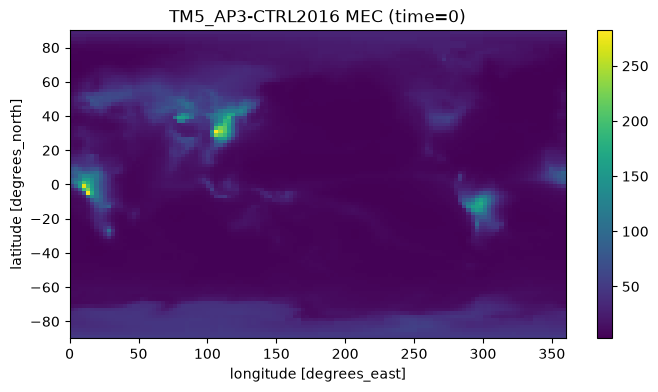

In [6]:
od = data[m].get('od550aer')
ld = data[m].get('loadss')

if od is None or ld is None:
    raise KeyError(f"Missing od550aer or loadss for model {m}")

MEC = od / (ld * 1e3)
print(ld)
mec_da = od['od550aer'] / (ld['loadss'] * 1e3)
mec_da.isel(time=0).plot(figsize=(8, 4))
plt.title(f"{m} MEC (time=0)")
plt.show()

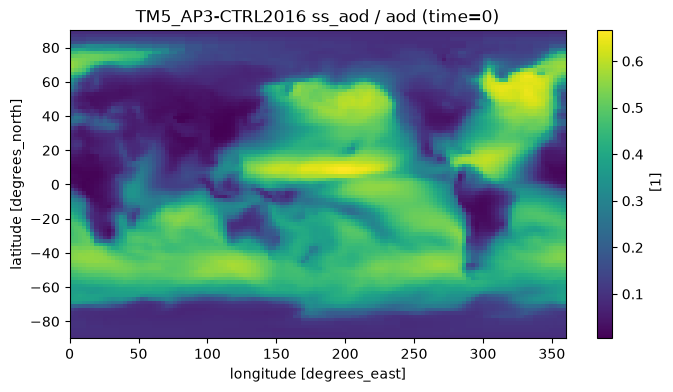

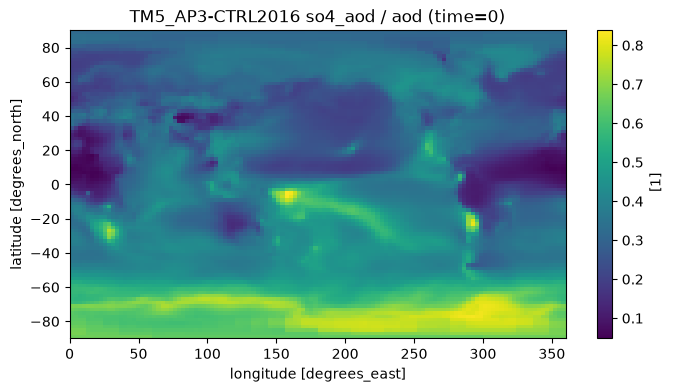

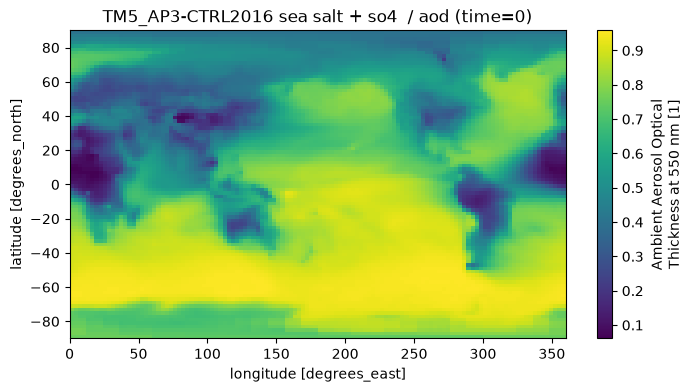

In [7]:
odSS = data[m].get('od550ss')
ss_r = odSS['od550ss'] / od['od550aer']
ss_r.isel(time=0).plot(figsize=(8, 4))
plt.title(f"{m} ss_aod / aod (time=0)")
plt.show()
odS04 = data[m].get('od550so4')
so4_r = odS04['od550so4'] / od['od550aer']
so4_r.isel(time=0).plot(figsize=(8, 4))
plt.title(f"{m} so4_aod / aod (time=0)")
plt.show()
ssso4_r = (odSS['od550ss'] + odS04['od550so4']) / od['od550aer']
ssso4_r.isel(time=0).plot(figsize=(8, 4))
plt.title(f"{m} sea salt + so4  / aod (time=0)")
plt.show()

In [ ]:
import logging

from aerocom_data import _get_dataarray, _align_da_to_ref


if USE_AGG_CACHE:
    print('USE_AGG_CACHE=True: skipping pre-aggregation derived vars')
else:
    derived_vars_pre = [dv for dv in ['MEC', 'MEC_ss', 'SSA', 'AE'] if dv not in DERIVED_VAR_AFTER_AGG]
    derived = {m: {} for m in models} 

    # Align sibling grids onto od550aer before MAC/SSA/AE (SPRINTARS lon micro-mismatch,
    # CAM5 od440 vs od550 resolution mismatch). Safe no-op when coords already match.
    n_aligned = 0
    for m in target_models:
        aerocom_data.align_model_grids(data[m], ref_var='od550aer', model_hint=m)
        n_aligned += 1
    print(f'Grid-aligned {n_aligned} models onto od550aer (when present).')
    ss_models = []

    for m in target_models:
        complete = True
        for dv in derived_vars_pre:
            # ds = aerocom_data.calculate_derived_var(data[m], m, dv)
            try:
                aod550 = _get_dataarray(data[m].get('od550aer'), 'od550aer')
                ds=None
                if dv == 'MEC':
                    load_keys = ['loadbc', 'loaddust', 'loadoa', 'loadso4', 'loadss']
                    loads = []
                    for k in load_keys:
                        if  data[m].get(k) is None:
                            continue
                        loads.append(_align_da_to_ref(
                            _get_dataarray( data[m].get(k), k), aod550, model_hint=f'{m}/{k}'
                        ))
                    missing = [k for k in ['od550aer'] + load_keys if data[m].get(k) is None]
                    if aod550 is None or not loads:
                        complete = False
                        raise ValueError(f"Missing {', '.join(missing)} for {m}/MEC.")
                    total_load = sum(loads)
                    if  total_load is None:
                        complete = False
                        raise KeyError(f"Missing total load for model {m}")
                    MEC = aod550 / (total_load * 1e3)
                    ds = MEC.to_dataset(name='MEC')
                if dv == 'MEC_ss':
                    loadss = _get_dataarray(data[m].get('loadss'), 'loadss')
                    aod550ss = _get_dataarray(data[m].get('od550ss'), 'od550ss')
                    if aod550ss is None or loadss is None:
                        complete = False
                        raise KeyError(f"Missing od550aer or loadss for model {m}")
                    MEC_ss = aod550ss / (loadss * 1e3)
                    ds = MEC_ss.to_dataset(name='MEC_ss')
                elif dv == 'SSA':
                    AAOD = _get_dataarray(data[m].get('abs550aer'), 'abs550aer') 
                    if AAOD is None :
                        complete = False
                        raise KeyError(f"Missing AAOD  for model {m}")
                    SSA = 1.0 - (AAOD / aod550)
                    ds = SSA.to_dataset(name='SSA')
                elif dv == 'AE':    
                    od440 = _get_dataarray(data[m].get('od440aer'), 'od440aer')
                    od550 = _get_dataarray(data[m].get('od550aer'), 'od550aer')
                    od865 = _get_dataarray(data[m].get('od865aer'), 'od865aer')
                    od870 = _get_dataarray(data[m].get('od870aer'), 'od870aer')
                    od_other = None
                    if od870 is not None:
                        od_other = od870
                        other_wavelength = 870
                    elif od865 is not None:
                        od_other = od865
                        other_wavelength = 865
                    else:
                        od_other = od440
                        other_wavelength = 440
        
                    if aod550 is None:
                        complete = False
                        raise ValueError(f"Missing 550nm AOD for {m}.")
                    elif od_other is None:
                        complete = False
                        raise ValueError(f"Missing other spectral bands to compute Angstrom Exponent for {m}.")
        
                    od_other = _align_da_to_ref(od_other, od550, model_hint=f'{m}/od_other') 
        
                    AE = - np.log(aod550 / od_other) /  np.log(550.0 / other_wavelength)
                    ds = AE.to_dataset(name='AE')
            except Exception as e:
                logging.warning(f"Could not calculate {dv} for {m}: {e}")


            if ds is None:
                derived[m][dv] = None
            else:
                derived[m][dv] = ds[list(ds.data_vars)[0]]
        if complete:
            ss_models.append(m)
        derived[m]['lifetime'] = None
        derived[m]['lifetime_ss'] = None


    data_derived = {}
    for m in models:
        data_derived[m] = {}
        for k, v in data[m].items():
            if v is not None:
                data_derived[m][k] = v[list(v.data_vars)[0]]
        for k, v in derived[m].items():
            if v is not None:
                data_derived[m][k] = v




INFO:   Grid-aligned od440aer -> od550aer for CAM5_CTRL2016/od440aer


INFO:   Grid-aligned od440aer -> od550aer for GEOS-Chem-v11-01_AP3-CTRL2016-PD/od440aer
INFO:   Grid-aligned od870aer -> od550aer for GEOS-Chem-v11-01_AP3-CTRL2016-PD/od870aer
INFO:   Grid-aligned abs550aer -> od550aer for GEOS-Chem-v11-01_AP3-CTRL2016-PD/abs550aer


Grid-aligned 24 models onto od550aer (when present).


In [ ]:
# ss_models
# ANALYSIS_REGIONS
# REGIONS['NAO']
# data_derived[m]['abs550aer']

<xarray.DataArray 'abs550aer' (time: 12, lat: 90, lon: 120)> Size: 518kB
dask.array<open_dataset-abs550aer, shape=(12, 90, 120), dtype=float32, chunksize=(12, 90, 120), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[us] 96B 2010-01-01 2010-02-01 ... 2010-12-01
  * lat      (lat) float64 720B -89.0 -87.0 -85.0 -83.0 ... 83.0 85.0 87.0 89.0
  * lon      (lon) float64 960B 1.5 4.5 7.5 10.5 ... 349.5 352.5 355.5 358.5
Attributes:
    units:          1
    cell_methods:   lon: lat: point time: mean
    standard_name:  atmosphere_absorption_optical_thickness_due_to_ambient_ae...
    long_name:      Ambient Absorption Aerosol Optical Thickness at 550 nm

In [42]:
if USE_AGG_CACHE:
    print('USE_AGG_CACHE=True: skipping regional aggregation')
else:
    SURFACE_TYPE = 'ocean'  # 'all', 'land', 'ocean', or None to use per-region defaults

    template = data[ss_models[0]]['od550aer'].isel(time=0)
    masks = {}
    for name in ANALYSIS_REGIONS:
        

        cfg = REGIONS[name]
        masks[name] = ct.create_region_mask(
            template,
            name=name,  # custom region name
            lon_range=cfg["lon_range"],
            lat_range=cfg["lat_range"],
            surface_type=cfg.get("surface_type", "all"),  # or SURFACE_TYPE override if you want
            mask_registry=masks,
        )
    print('Regions created (ANALYSIS_REGIONS):', list(masks.keys()))
    variables_to_aggregate = [v for v in variables_pre_aggregated if v not in DERIVED_VAR_AFTER_AGG]
    model_monthly = {
        region: {
            var: setup.aggregate_region(data_derived, var, region, masks, region=REGIONS, return_time_series=True,
                                  skipna=(var in variables_to_aggregate))
            for var in variables_to_aggregate
        }
        for region in ANALYSIS_REGIONS
    }
    model_seasonal = {
        region: {
            var: setup.aggregate_region(data_derived, var, region, masks, region=REGIONS, return_time_series=False,
                                  skipna=(var in variables_to_aggregate))
            for var in variables_to_aggregate
        }
        for region in ANALYSIS_REGIONS
    }


Regions created (ANALYSIS_REGIONS): ['NAO', 'ANTAO']


sum= 0.0 min= 0.0 max= 0.0


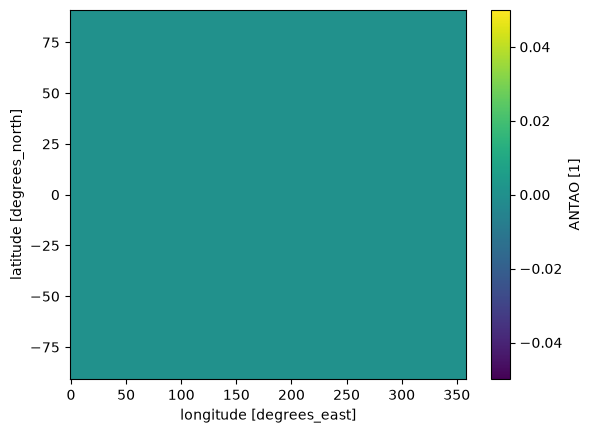

In [ ]:
m = masks["ANTAO"]
print("sum=", float(m.sum()), "min=", float(m.min()), "max=", float(m.max()))
m.plot()  # direct check

NAO (280.0, 360.0) (20.0, 60.0) None
ANTAO (0.0, 360.0) (-60.0, -90.0) None


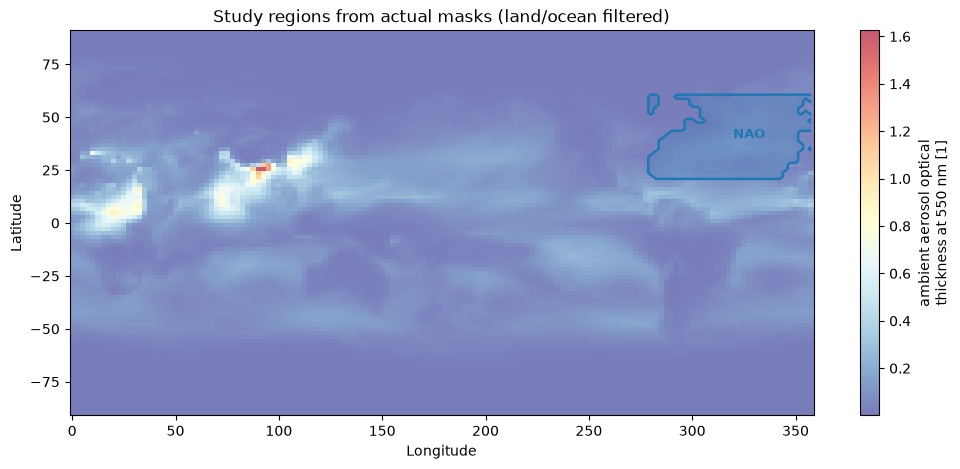

In [ ]:
import matplotlib.pyplot as plt
for name in ANALYSIS_REGIONS:
    m = masks[name]
    print(name, m.attrs.get("lon_range"), m.attrs.get("lat_range"), m.attrs.get("surface_type"))
# background field (optional)
bg = sample_field
if "time" in bg.dims:
    bg = bg.isel(time=0)

fig, ax = plt.subplots(figsize=(12, 5))
bg.plot(ax=ax, cmap="RdYlBu_r", add_colorbar=True, alpha=0.65)

# one color per region
colors = plt.cm.tab10(np.linspace(0, 1, max(len(ANALYSIS_REGIONS), 1)))

for i, name in enumerate(ANALYSIS_REGIONS):
    m = masks[name]
    if "time" in m.dims:
        m = m.isel(time=0)
    m = m.astype(float)

    # fill masked area lightly
    ax.contourf(
        m["lon"], m["lat"], m.values,
        levels=[0.5, 1.5], colors=[colors[i]], alpha=0.20
    )
    # draw exact mask boundary
    ax.contour(
        m["lon"], m["lat"], m.values,
        levels=[0.5], colors=[colors[i]], linewidths=1.8
    )

    # label near center of masked pixels
    yy, xx = np.where(np.isfinite(m.values) & (m.values > 0.5))
    if len(xx) > 0:
        lon_c = float(m["lon"].values[xx].mean())
        lat_c = float(m["lat"].values[yy].mean())
        ax.text(lon_c, lat_c, name, color=colors[i], fontsize=9, weight="bold")

ax.set_title("Study regions from actual masks (land/ocean filtered)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

if SAVE_FIGURE:
    save_path = FIGURE_DIR / "seasalt_regions_mask_map.png"
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    print(f"Saved regional mask map: {save_path}")

plt.show()

In [ ]:
# agg['NAO']['loadss']
# print(model_seasonal[region].keys())

{'CAM5-ATRAS_AP3-CTRL': 2.1097233696632295e-05,
 'CAM5.3-Oslo_AP3-CTRL2016-PD': 1.5134118052339235e-05,
 'CAM5_CTRL2016': 2.499825642350256e-05,
 'EC-Earth3-AerChem-met2010_AP3-CTRL2019': 1.7153911747508773e-05,
 'ECHAM6-HAM2_AP3-CTRL2016-PD': 3.1002903202772446e-05,
 'ECHAM6-SALSA_CTRL2016-PD': 9.517996803552413e-06,
 'ECHAM6.3-HAM2.3-met2010_AP3-CTRL': 2.7564484444218406e-05,
 'ECHAM6.3-SALSA2.0-met2010_AP3-CTRL': 2.7008458943230458e-05,
 'ECMWF-IFS-CY42R1-CAMS-RA-CTRL_AP3-CTRL2016-PD': 1.9306173715527322e-05,
 'ECMWF-IFS-CY45R1-CAMS-CTRL-met2010_AP3-CTRL': 8.281560437591482e-05,
 'ECMWF-IFS-CY46R1-CAMS-CTRL-met2010_AP3-CTRL': 7.4331902179177e-05,
 'ETHZ-ECHAM6-HAM2_CTRL2015': 2.8452519469735278e-05,
 'GEOS-Chem-v11-01_AP3-CTRL2016-PD': 1.1829041184791473e-05,
 'GEOS-i33p2-met2010_AP3-CTRL': 2.6033404863251363e-05,
 'GFDL-AM4-met2010_AP3-CTRL': 2.3306670901367918e-05,
 'GISS-ModelE2p1p1-OMA_AP3-CTRL': 2.1217777676040633e-05,
 'HadGEM3-GA7.1_AP3-CTRL2016-PD': 1.488515038455467e-05,
 '

In [32]:
from notebook_setup import _lifetime_from_load_flux
if USE_AGG_CACHE:
    print('USE_AGG_CACHE=True: skipping regional aggregation')
else:
    # setup.compute_derived_after_aggregation(
    #     model_monthly, model_seasonal, DERIVED_VAR_AFTER_AGG,
    #     use_deposition_for_lifetime=USE_DEPOSITION_FOR_LIFETIME,
    # ) who and how... 
    flux_key = 'depss' if USE_DEPOSITION_FOR_LIFETIME else 'emiss'
    for agg in (model_monthly, model_seasonal):
        for region in ANALYSIS_REGIONS:
            load = agg[region].get('loadss')
            flux = agg[region].get(flux_key)
            if load is None or flux is None:
                logging.warning(f"Missing load or flux for {region} in {agg}. Skipping lifetime calculation.")
                continue
            agg[region]['lifetime_ss'] = _lifetime_from_load_flux(
                            load, flux, 'lifetime_ss', region
                        )
    print('\nModel seasonal availability:')
            
    for region in ANALYSIS_REGIONS:
        for var in ['MEC_ss', 'SSA', 'AE', 'lifetime_ss', 'precip', 'abs550aer']:
            n = len(model_seasonal[region].get(var, {}))
            print(f'  {region} {var}: {n} models')



Model seasonal availability:
  NAO MEC_ss: 23 models
  NAO SSA: 22 models
  NAO AE: 22 models
  NAO lifetime_ss: 23 models
  NAO precip: 18 models
  NAO abs550aer: 24 models
  ANTAO MEC_ss: 23 models
  ANTAO SSA: 22 models
  ANTAO AE: 22 models
  ANTAO lifetime_ss: 23 models
  ANTAO precip: 18 models
  ANTAO abs550aer: 24 models



--- Regional map ---
  Background field from CAM5-ATRAS_AP3-CTRL
/scistor/guest/gbb083/.local/share/cartopy


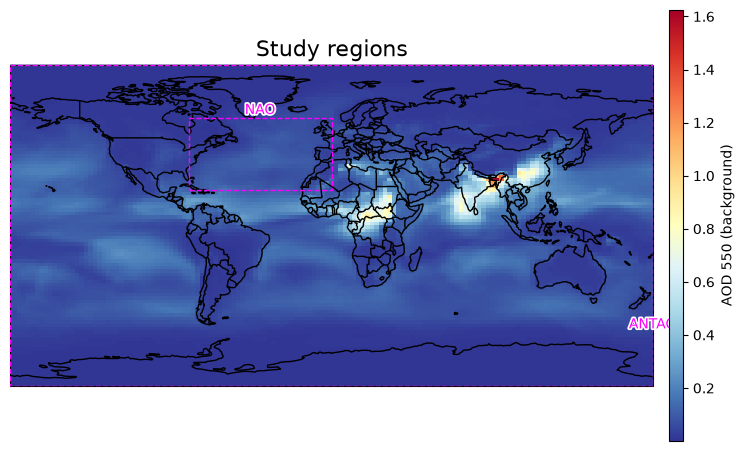

In [34]:
print('\n--- Regional map ---')
# Prefer in-memory `data` from the full pipeline; otherwise load one NetCDF field.
_sample_field = None
_sample_model = None
if 'data' in dir() and data:
    _sample_model = next(
        (m for m in models if data.get(m) and data[m].get('od550aer') is not None),
        None,
    )
    if _sample_model is not None:
        _ds = data[_sample_model]['od550aer']
        _sample_field = _ds['od550aer'] if hasattr(_ds, '__contains__') and 'od550aer' in _ds else (
            _ds[list(_ds.data_vars)[0]] if hasattr(_ds, 'data_vars') else _ds
        )
        if 'time' in getattr(_sample_field, 'dims', ()):
            _sample_field = _sample_field.isel(time=0)

if _sample_field is None:
    _candidates = list(models) if 'models' in dir() and models else []
    for _m in _candidates:
        _fpath = project_root / 'Data' / 'AP3_processed_monthly' / 'od550aer' / f'{_m}_od550aer_processed.nc'
        if not _fpath.exists():
            continue
        _ds = xr.open_dataset(_fpath, engine='netcdf4')
        _ds = aerocom_data.standardize_dataset(_ds, 'od550aer').load()
        _ds.close()
        _ds = aerocom_data.normalize_dataset_time(_ds, var_hint=f'{_m}/od550aer', year=2010)
        _sample_field = _ds[list(_ds.data_vars)[0]].isel(time=0)
        _sample_model = _m
        if 'data' not in dir() or data is None:
            data = {}
        data.setdefault(_m, {})['od550aer'] = _ds
        break

if _sample_field is None:
    raise FileNotFoundError(
        'Could not load a background od550aer field for the study-regions map. '
        'Check Data/AP3_processed_monthly/od550aer/ or set USE_AGG_CACHE=False.'
    )
sample_model = _sample_model
sample_field = _sample_field
print(f'  Background field from {sample_model}')

region_boxes = {
    name: (
        REGIONS[name]['lon_range'][0], REGIONS[name]['lon_range'][1],
        REGIONS[name]['lat_range'][0], REGIONS[name]['lat_range'][1],
    )
    for name in ANALYSIS_REGIONS
}
fig = ct.fake_uba_map(
    lon=sample_field.lon.values,
    lat=sample_field.lat.values,
    c_array=sample_field.values,
    labels='AOD 550 (background)',
    title='Study regions',
    region_boxes=region_boxes,
    show_region_labels=True,
    region_edgecolor='magenta',
    region_linewidth=1.0,
    mycolor='RdYlBu_r',
    cbar_orientation='vertical',
    cbar_extend='neither',
    show=False,
)
if SAVE_FIGURE:
    save_path = FIGURE_DIR / 'study_regions_map.png'
    fig.savefig(save_path, bbox_inches='tight', dpi=300)
    print(f'Saved regional map: {save_path}')
    plt.close(fig)
